<a href="https://colab.research.google.com/github/lt33tx/Landon_Tinch_DTSC3020_Fall2025-/blob/main/Copy_of_INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [38]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> False Positives are way more painful for a mobile carrier because they end up blocking messages that matter a real, important text from the boss or a family emergency could get stopped by a filter that's too eager. That's not just inconvenient; it's risky. On the flip side, a False Negative just lets some spam sneak into the inbox. Annoying? Sure. But the user can just delete it. Nobody gets hurt.


**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Precision should be front and center as the main metric. If we push to maximize Precision, we're keeping mistakes those crucial False Positives to a minimum. Optimizing Recall sounds tempting if you want to catch more spam, but it comes at the ugly cost of blocking harmless texts, and that's just not worth it.


**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> in Step 2B, you'll see just how misleading accuracy gets. A dummy model that always predicts "ham" nails an 86.6% accuracy. Why? Because the dataset is mostly real messages. But that model doesn't actually do anything useful it misses every single spam text (scoring 0.0% on Recall and F1-Score). This just proves that accuracy is a terrible way to measure performance when your classes are uneven


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [39]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6% misleadingly high
  Recall    = 0.0% catches zero spam
  F1-Score  = 0.0%


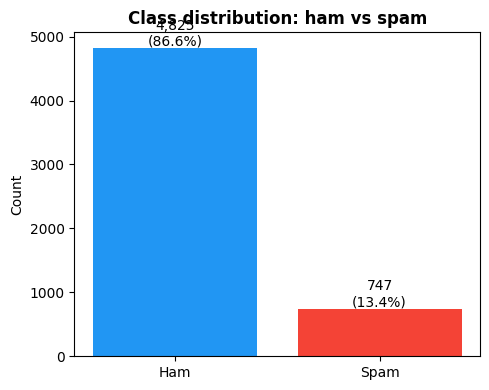

In [40]:
# Write your code here1

# calculate the number of spam and ham messages along with the overall spam rate
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# create a simple baseline model that predicts every message as ham for comparison
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%} misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%} catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

# generate a bar chart to visually compare the counts of ham and spam messages
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [41]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


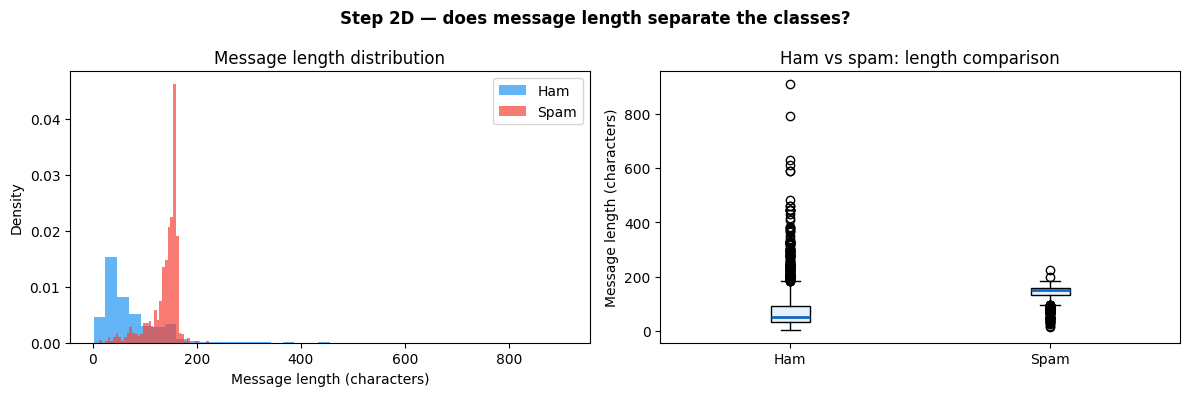

In [42]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [43]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [44]:
# Write your code here

# define an updated feature-building function that extends the original features with additional indicators
def build_features_v2(df):
    d = build_features(df)
    msg = d['message'].str.lower()

    # Spam usually wants you to "text" or "reply" to a number
    d['has_txt_reply'] = msg.str.contains(r'\b(txt|text|reply)\b', regex=True).astype(int)

    # Checking for URLs since spam loves to send shady links
    d['has_url'] = msg.str.contains(r'(http|www\.)', regex=True).astype(int)

    return d

# apply the updated feature function to the dataset to generate the full feature set
df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
# create a list of feature columns by excluding non-feature fields like labels and raw text
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
# iterate through each feature and compare its average presence in spam vs ham messages
print('All features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in feature_cols:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')

All features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%
has_txt_reply      40.7%    2.5%  +38.2%
has_url            14.3%    0.0%  +14.3%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


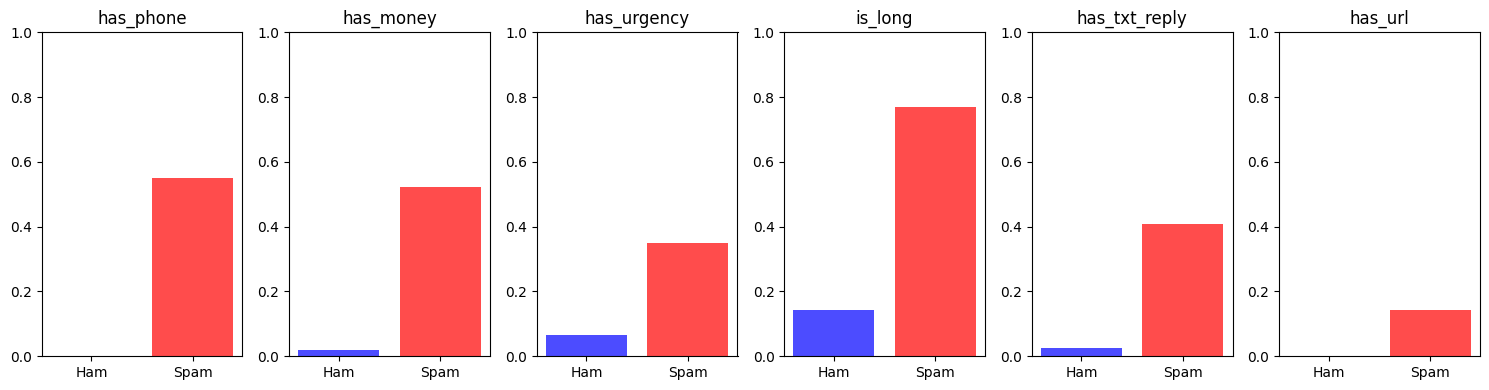

In [45]:
# Write your code here

# Create a row of subplots, one for each feature we want to compare
fig, axes = plt.subplots(1, len(feature_cols), figsize=(15, 4))

# Loop through each feature and calculate average values for spam vs ham emails
for i, f in enumerate(feature_cols):
    sp_rate = df[df['spam']==1][f].mean()
    ha_rate = df[df['spam']==0][f].mean()

    # Plot a bar chart comparing ham and spam averages for the current feature
    axes[i].bar(['Ham', 'Spam'], [ha_rate, sp_rate], color=['blue', 'red'], alpha=0.7)
    axes[i].set_title(f)
    axes[i].set_ylim(0, 1)

# Adjust layout so plots don’t overlap and display the figure
plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 and 2 — name and explanation:*
> For custom features, I built has_txt_reply, which checks for "txt," "text," or "reply." Then there's has_url, which looks for "http" or "www." I figured "txt" or "reply" would scream spam since those call-to-actions fill promo spam texts like "Reply STOP" or "Text YES." As for has_url, it's handy because modern SMS spam relies on tricking people into clicking sketchy links hardly something you'd see in casual conversations.


**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
>  Looking over Step 3B, the has_phone starter feature stands out with the biggest gap (+55.1%). But from my custom features, has_txt_reply shows a solid +38.2% gap. That matters. When a Decision Tree picks a root node, a huge gap means you're getting massive Information Gain. The tree slices the dataset cleanly, and you end up with pure child nodes which just makes everything that follows easier.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> modern phishing texts don't even trip these features. Take something like "Your account is locked, please sign in securely to verify." That message avoids caps, skips prizes and cash so has_money isn't triggered, doesn't mention "text" or "reply" so has_txt_reply fails, and if the link is disguised, my has_url feature totally misses it. This lets professional scams slip right through simple keyword filters.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [46]:
# Write your code here

# Separate features and labels from the dataframe
X = df[feature_cols].values
y = df['spam'].values

# Split the dataset into training and testing sets while keeping class distribution consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Print out the sizes and spam rates of each split to verify the distribution
print(f"Train split size: {len(X_train)} | Spam rate: {y_train.mean():.1%}")
print(f"Test split size:  {len(X_test)} | Spam rate: {y_test.mean():.1%}")

Train split size: 4179 | Spam rate: 13.4%
Test split size:  1393 | Spam rate: 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> We use stratify=y so that the 13.4% spam ratio stays the same across both training and test splits. The Step 4A printout confirms this. If we skipped stratifying on a lopsided dataset, the test set could wind up with almost zero spam or way too much. That would either prevent the model from learning what spam looks like, or mess up our evaluation metrics.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> If I had a small dataset, I'd go with k-fold cross-validation instead of a one-shot 75/25 train/test split. With a single split, your results come down to luck a weird distribution could make your model look way better or way worse than it really is. Cross-validation solves this; it trains and tests across multiple folds, and averages out the weirdness, giving you a much clearer sense of how your model performs in real life.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 14


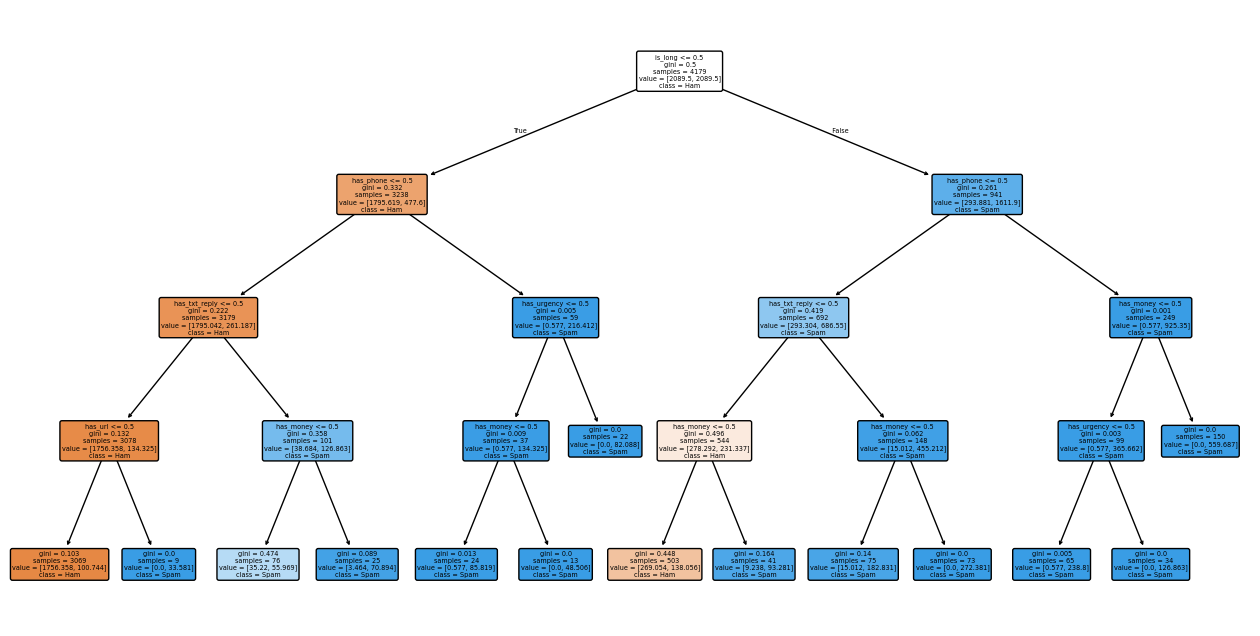

|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_txt_reply <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_txt_reply >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_txt_reply <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_txt_reply >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1

In [47]:
# Write your code here

# Initialize a decision tree with limited depth and balanced class weights
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')

# Train the decision tree on the training data
dt.fit(X_train, y_train)

# Print how many leaves the trained tree has
print(f"Number of leaves: {dt.get_n_leaves()}")

# Visualize the tree structure with labeled nodes
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['Ham', 'Spam'], filled=True, rounded=True)
plt.show()

# Print the textual representation of the tree for easier interpretation
print(export_text(dt, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


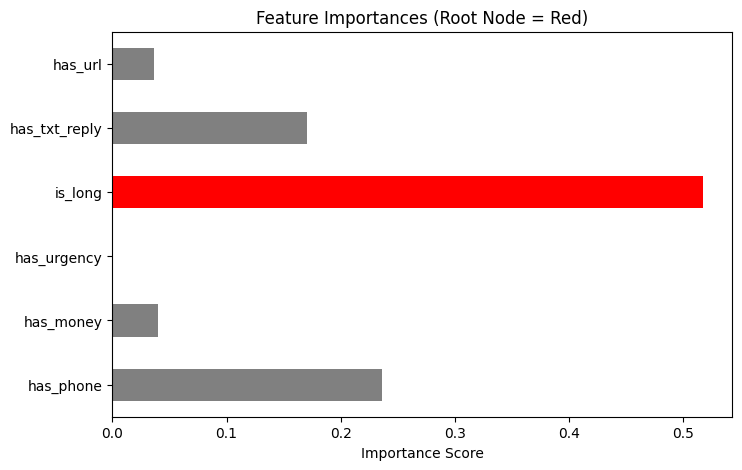

In [48]:
# Write your code here

# Get feature importance scores from the trained decision tree
importances = pd.Series(dt.feature_importances_, index=feature_cols)

# Highlight the most important feature in red, others in gray
bar_colors = ['red' if val == importances.max() else 'gray' for val in importances]

# Plot a horizontal bar chart showing feature importances
importances.plot(kind='barh', color=bar_colors, figsize=(8, 5))
plt.title("Feature Importances (Root Node = Red)")
plt.xlabel("Importance Score")
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


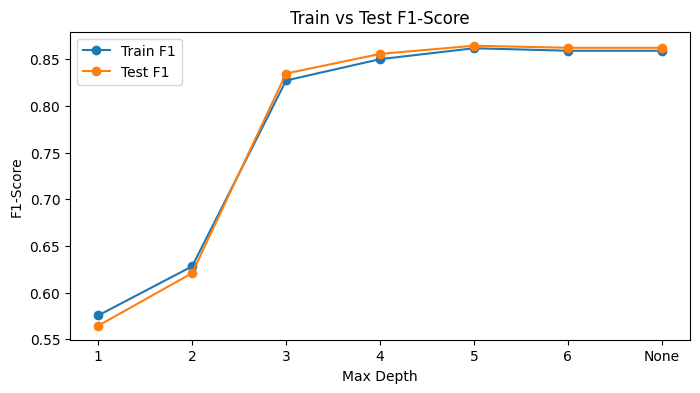

In [49]:
# Write your code here

# Set different max depths to test how tree depth affects performance
depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

# Train a decision tree for each depth and record F1 scores on train and test sets
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    train_f1.append(f1_score(y_train, model.predict(X_train)))
    test_f1.append(f1_score(y_test, model.predict(X_test)))

# Convert depths to strings for plotting on x-axis
x_ticks = [str(d) for d in depths]

# Plot train and test F1 scores vs tree depth
plt.figure(figsize=(8, 4))
plt.plot(x_ticks, train_f1, label='Train F1', marker='o')
plt.plot(x_ticks, test_f1, label='Test F1', marker='o')
plt.xlabel("Max Depth")
plt.ylabel("F1-Score")
plt.title("Train vs Test F1-Score")
plt.legend()
plt.show()

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [50]:
# Write your code here

# Initialize a Bernoulli Naive Bayes model
nb = BernoulliNB()

# Train the model on the training data
nb.fit(X_train, y_train)
print("trained successfully!")

trained successfully!


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


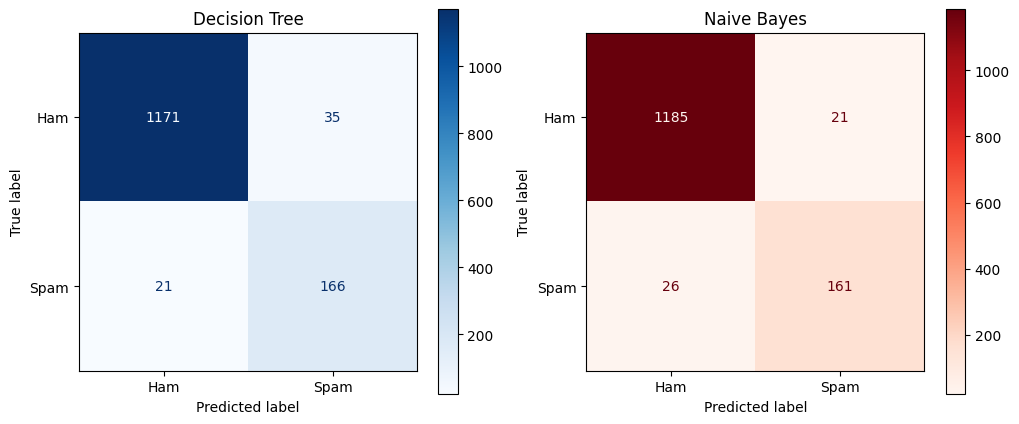

Decision Tree:
  TP: 166 | FP: 35 | FN: 21 | TN: 1171

Naive Bayes:
  TP: 161 | FP: 21 | FN: 26 | TN: 1185


In [51]:
# Write your code here

# Predict labels on the test set using both models
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

# Create side-by-side subplots to visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the confusion matrix for the Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['Ham', 'Spam'], cmap='Blues', ax=axes[0])
axes[0].set_title("Decision Tree")

# Plot the confusion matrix for the Naive Bayes model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, display_labels=['Ham', 'Spam'], cmap='Reds', ax=axes[1])
axes[1].set_title("Naive Bayes")

plt.show()

# Calculate and print TP, FP, FN, TN for Decision Tree
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(y_test, y_pred_dt).ravel()
print("Decision Tree:")
print(f"  TP: {tp_dt} | FP: {fp_dt} | FN: {fn_dt} | TN: {tn_dt}")

# Calculate and print TP, FP, FN, TN for Naive Bayes
tn_nb, fp_nb, fn_nb, tp_nb = confusion_matrix(y_test, y_pred_nb).ravel()
print("\nNaive Bayes:")
print(f"  TP: {tp_nb} | FP: {fp_nb} | FN: {fn_nb} | TN: {tn_nb}")

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.959799,0.825871,0.887701,0.855670
1,Naive Bayes,0.966260,0.884615,0.860963,0.872629


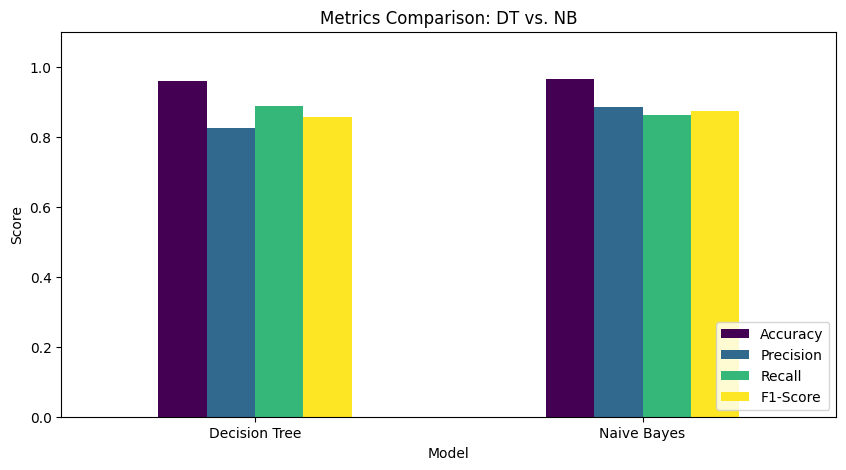

In [52]:
# Write your code here

# Create a dataframe summarizing accuracy, precision, recall, and F1-score for both models
data = {
    'Model': ['Decision Tree', 'Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_nb)],
    'Precision': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_nb)],
    'Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_nb)],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_nb)]
}
metrics_df = pd.DataFrame(data)

# Display the metrics dataframe
display(metrics_df)

# Plot a bar chart comparing all metrics between the two models
metrics_df.set_index('Model').plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Metrics Comparison: DT vs. NB")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [53]:
# Write your code here

# Set up stratified 5-fold cross-validation to keep class balance in each fold
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Decision Tree and Naive Bayes models using F1-score across folds
dt_cv = cross_val_score(dt, X, y, cv=cv_folds, scoring='f1')
nb_cv = cross_val_score(nb, X, y, cv=cv_folds, scoring='f1')

# Print the average F1-score from cross-validation for both models
print(f"Decision Tree CV Avg F1-Score: {dt_cv.mean():.3f}")
print(f"Naive Bayes CV Avg F1-Score:   {nb_cv.mean():.3f}")

Decision Tree CV Avg F1-Score: 0.844
Naive Bayes CV Avg F1-Score:   0.885


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> Step 6A's confusion matrices put the models side by side. The Decision Tree nailed 166 spam (True Positives), missed 21 (False Negatives), and wrongly blocked 35 legit texts (False Positives).

*Naive Bayes:*
> Naive Bayes got 161 spam, missed 26, but only blocked 21 legit messages. So Naive Bayes is slightly more careful about flagging stuff as spam.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> since Precision is the top metric chosen for minimizing False Positives Naive Bayes wins. Step 6B shows Naive Bayes hitting about 0.884 Precision, Decision Tree at 0.825. Five-fold cross-validation in Step 6C backs this up, showing Naive Bayes keeps a higher average F1-Score (0.885 vs 0.844) across different data splits.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> If we're deploying this automated SMS spam filter, go with Naive Bayes. Backtesting showed it reached 88.4% Precision, way better than Decision Tree's 82.5%. That means we're far less likely to accidentally block users' important messages. But here's the downside: Naive Bayes treats every word or feature independently, without caring about context or sequence. To catch smarter threats, we should upgrade to TF-IDF or n-grams, so the system actually pays attention to frequency and context.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> has_txt_reply and has_money two features I built would flop against modern spam. Scammers have learned to dodge keyword filters. Instead of hyping up "CASH PRIZES" or saying "TXT NOW," today's smishing attacks are smooth and conversational. They mimic legit alerts, like fake USPS delivery updates or Netflix billing errors, with no obvious spammy keywords. Hardcoded rules just can't keep up.
